<a href="https://colab.research.google.com/github/Mallika-Rajpal/DiabeAI/blob/main/Diabetes_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/diabetes 2.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


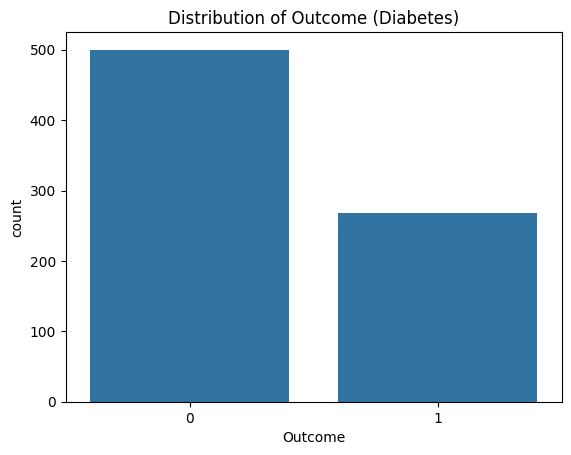

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Outcome (Diabetes)")
plt.show()

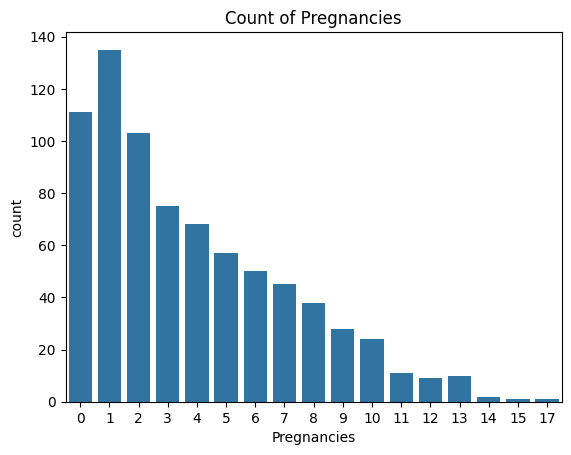

In [ ]:
sns.countplot(x='Pregnancies', data=df)
plt.title('Count of Pregnancies')
plt.show()

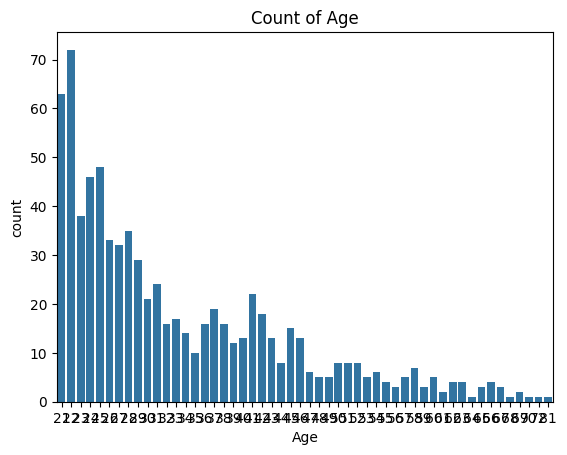

In [ ]:
sns.countplot(x='Age', data=df)
plt.title('Count of Age')
plt.show()

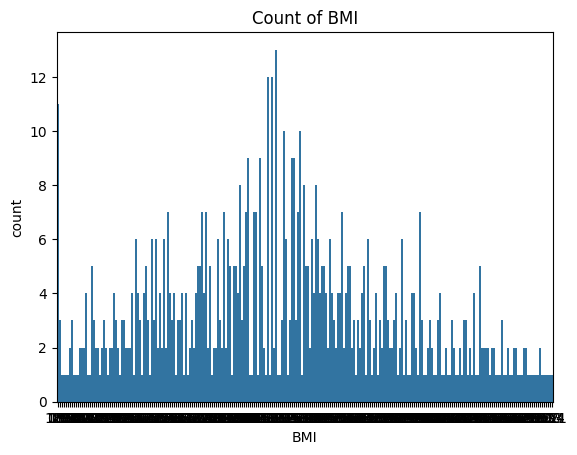

In [ ]:
sns.countplot(x='BMI', data=df)
plt.title('Count of BMI')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f'Logistic Regression Accuracy: {acc_log_reg}')


Logistic Regression Accuracy: 0.7532467532467533


In [ ]:
# k-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'k-NN Accuracy: {acc_knn}')

k-NN Accuracy: 0.6948051948051948


In [ ]:
# Decision Trees
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {acc_dt}')

Decision Tree Accuracy: 0.7402597402597403


In [ ]:
# Random Forests
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf}')

Random Forest Accuracy: 0.7467532467532467


In [ ]:
# Support Vector Machines (SVM)
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'SVM Accuracy: {acc_svm}')

SVM Accuracy: 0.7337662337662337


                 Model  Accuracy
0  Logistic Regression  0.753247
1                 k-NN  0.694805
2        Decision Tree  0.753247
3        Random Forest  0.746753
4                  SVM  0.733766


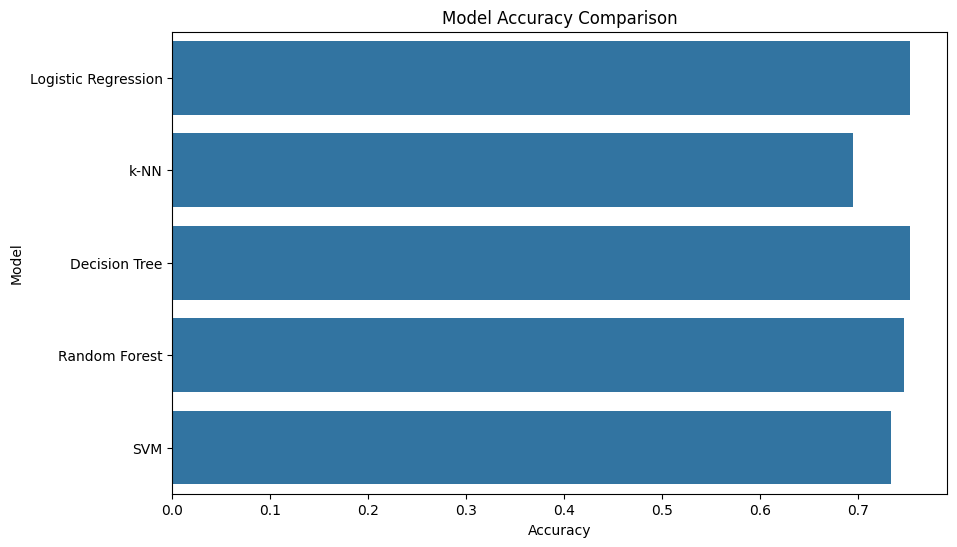

In [ ]:
# Create a DataFrame to compare accuracies
model_names = ['Logistic Regression', 'k-NN', 'Decision Tree', 'Random Forest', 'SVM']
accuracies = [acc_log_reg, acc_knn, acc_dt, acc_rf, acc_svm]

comparison_df = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})

# Display comparison
print(comparison_df)

# Plot comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=comparison_df)
plt.title('Model Accuracy Comparison')
plt.show()


In [ ]:
# Feature importance from Random Forest
rf_importances = rf.feature_importances_

# Create a DataFrame for visualization
rf_feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print(rf_feature_importance_df)


                    Feature  Importance
1                   Glucose    0.247788
5                       BMI    0.166369
7                       Age    0.148462
6  DiabetesPedigreeFunction    0.121789
2             BloodPressure    0.091253
0               Pregnancies    0.079070
4                   Insulin    0.075356
3             SkinThickness    0.069913


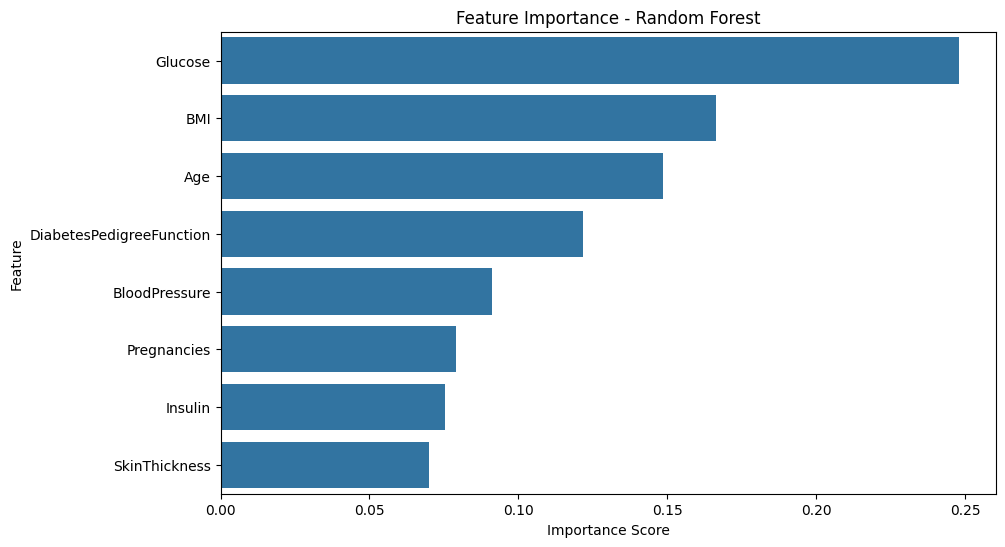

In [ ]:
# Plotting Feature Importance (Random Forest example shown, repeat for others)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


In [ ]:
# Feature importance from Decision Tree
dt_importances = dt.feature_importances_  # Assuming `dt` is your Decision Tree model

# Create a DataFrame for visualization
dt_feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)

print(dt_feature_importance_df)


                    Feature  Importance
1                   Glucose    0.334284
2             BloodPressure    0.158250
5                       BMI    0.154286
7                       Age    0.106644
6  DiabetesPedigreeFunction    0.088075
4                   Insulin    0.066492
3             SkinThickness    0.052270
0               Pregnancies    0.039698


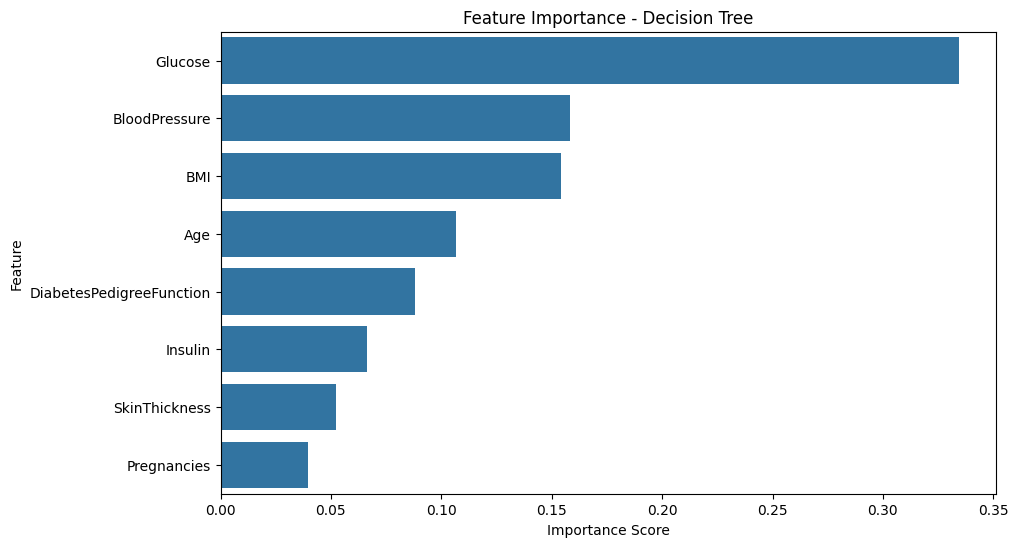

In [ ]:
# Plotting Feature Importance for Decision Tree
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_feature_importance_df)
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


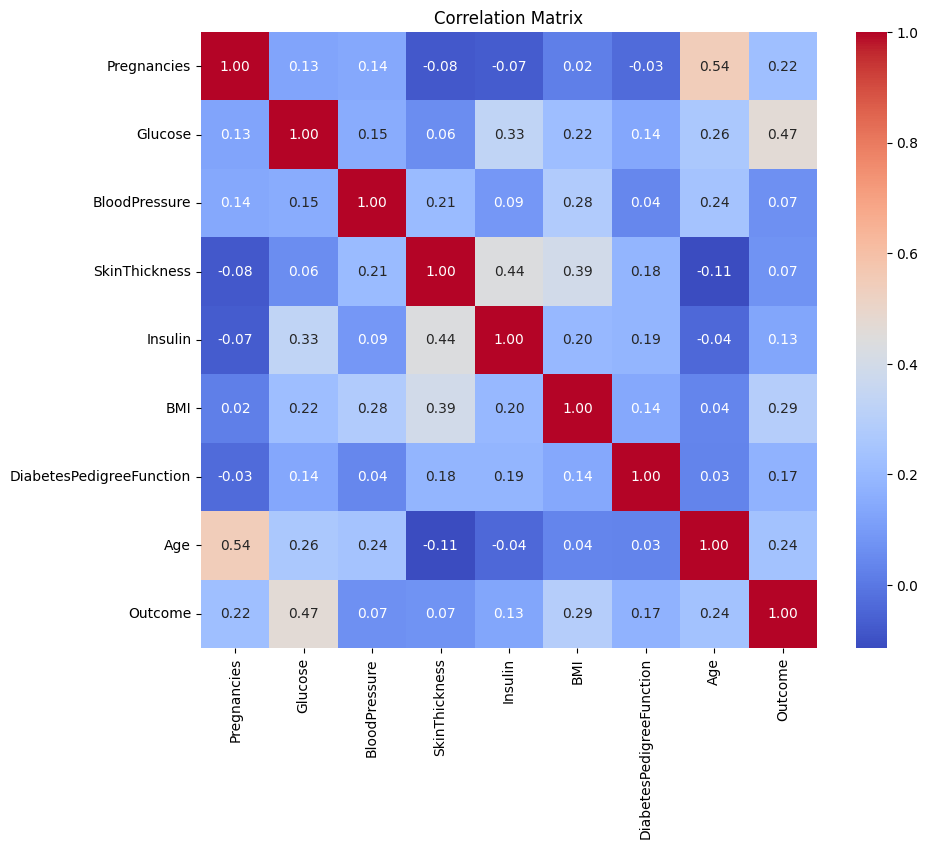

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()  # Calculate correlations
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()


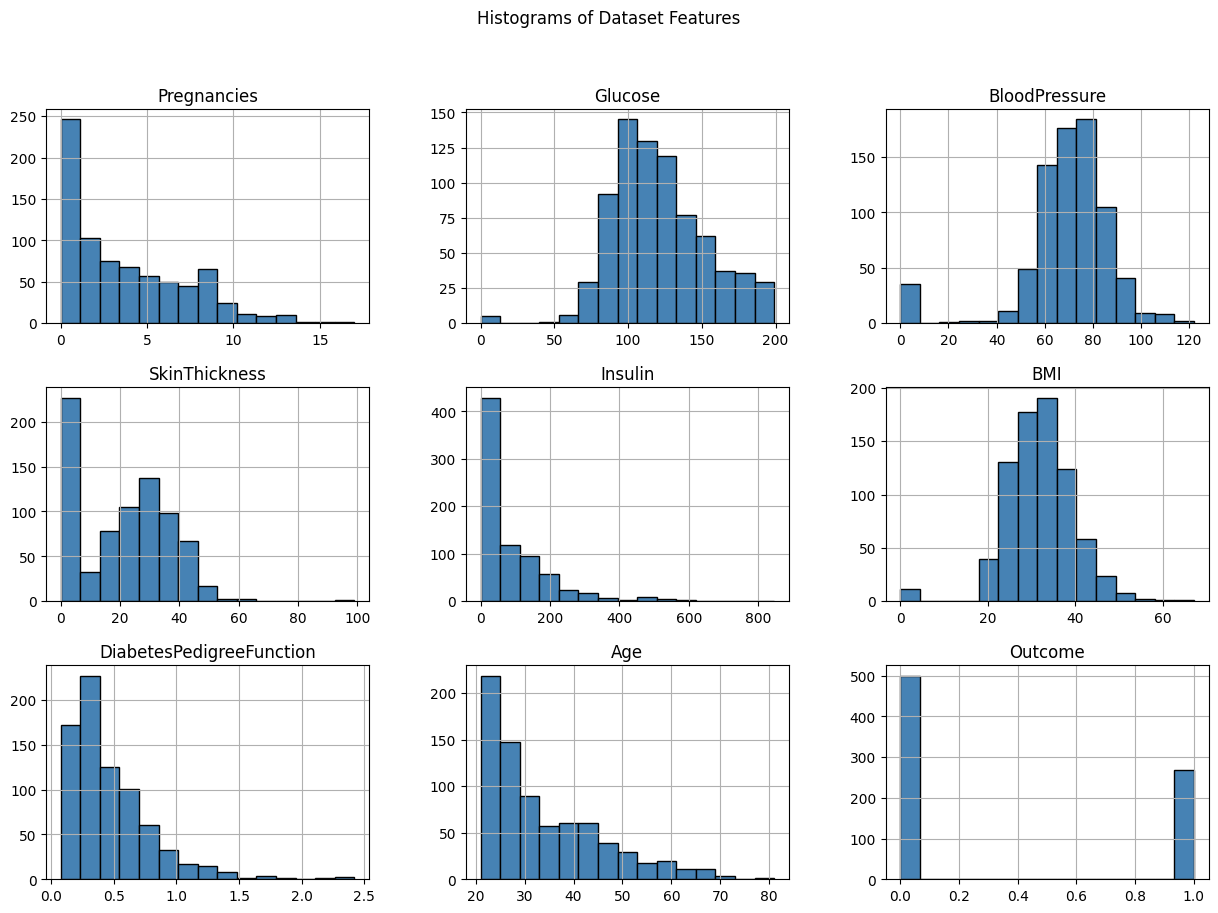

In [ ]:
# Create histograms for each feature
df.hist(bins=15, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Dataset Features')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Split the data into training and testing sets
X = df.drop(columns=['Outcome'])  # Features
y = df['Outcome']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

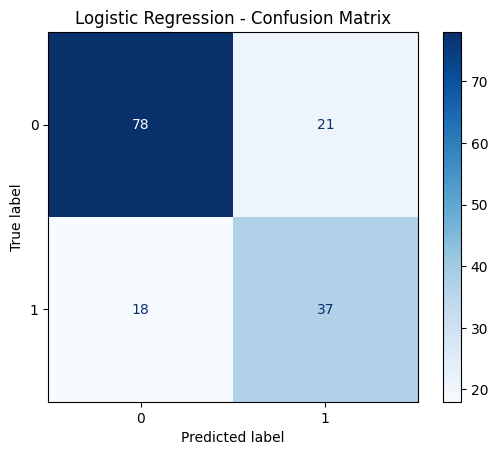

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


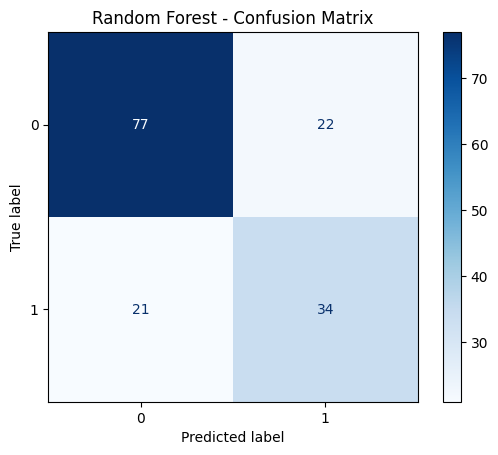

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()


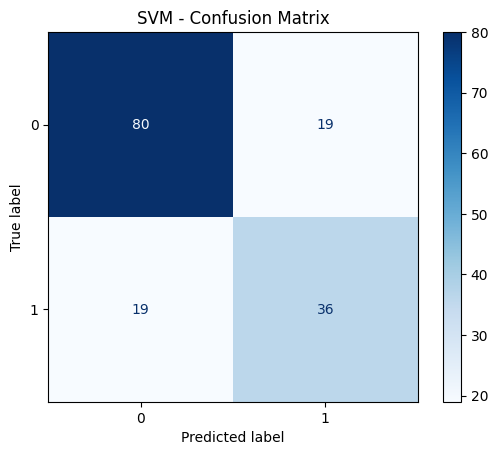

In [ ]:
from sklearn.svm import SVC

# Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp_svm.plot(cmap='Blues')
plt.title('SVM - Confusion Matrix')
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train the k-NN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_model.classes_)
disp_knn.plot(cmap='Blues')
plt.title('k-NN - Confusion Matrix')
plt.show()
